In [188]:
# csvファイルの読み込み
import pandas as pd
data = pd.read_csv('../data/clean/clean_NVDA_data.csv')

In [189]:
data.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-03,5.876163,5.919972,5.827126,5.852018,205384000
1,2020-01-06,5.900806,5.906033,5.756684,5.782820,262636000
2,2020-01-07,5.972244,6.018045,5.884128,5.929182,314856000
3,2020-01-08,5.983446,6.024766,5.927938,5.968013,277108000
4,2020-01-09,6.049160,6.121595,5.995395,6.069821,255112000


In [190]:
data.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [191]:
data = pd.read_csv('../data/target_label_data/label_NVDA_data.csv')

In [194]:
data.dtypes

Date         datetime64[ns]
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Peaklabel             int64
dtype: object

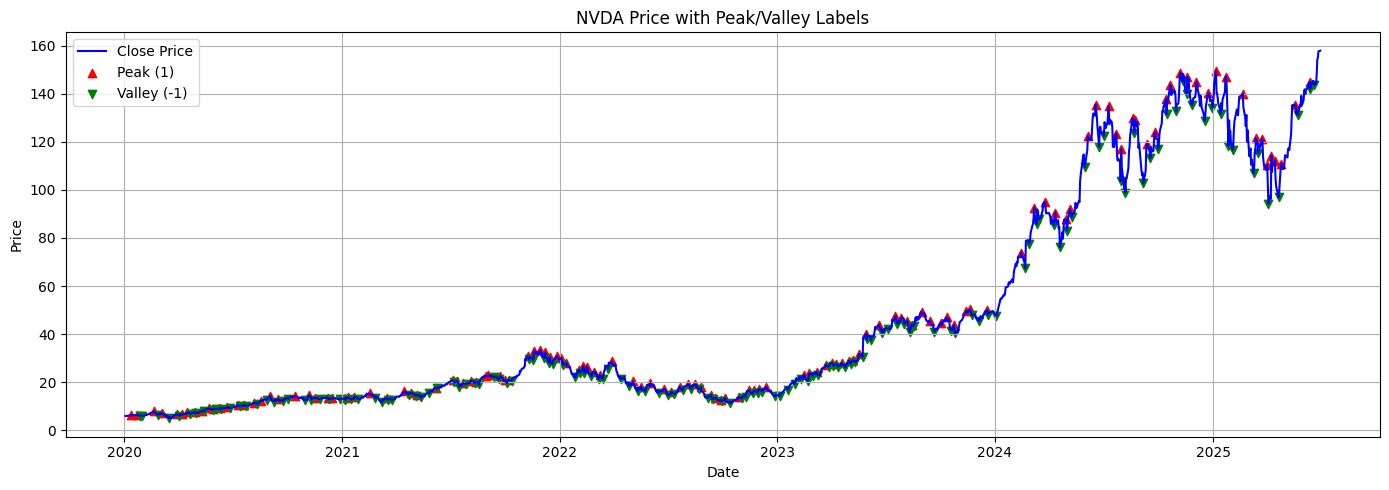

In [198]:
import matplotlib.pyplot as plt

# 日付型に変換
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# 可視化：Close価格 + PeakLabel（山=赤点、谷=緑点）
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')

# 山（Peak=1）の位置に赤丸
peak_dates = data[data['Peaklabel'] == 1]
plt.scatter(peak_dates['Date'], peak_dates['Close'], color='red', label='Peak (1)', marker='^')

# 谷（Peak=-1）の位置に緑丸
valley_dates = data[data['Peaklabel'] == -1]
plt.scatter(valley_dates['Date'], valley_dates['Close'], color='green', label='Valley (-1)', marker='v')

plt.title(f"NVDA Price with Peak/Valley Labels")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
